In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'axes.linewidth': 0.8,
})

df = pd.read_csv('sweep_results_time_analysis.csv')
df = df[df['avg_runtime_per_batch_s'] != 'timeout']
df['avg_runtime_per_batch_s'] = df['avg_runtime_per_batch_s'].astype(float)
df.head()

,seed,scheduler,tx_size_dist,batch_size,num_executors,avg_remote_reads_per_batch,avg_runtime_per_batch_s
0,0,best_program,medium,128,4,248.2,0.000244
1,0,paper,medium,128,4,210.4,0.026976
2,0,best_program,medium,128,8,309.8,0.000230
3,0,paper,medium,128,8,276.2,0.058221
4,0,best_program,medium,128,16,362.2,0.000216


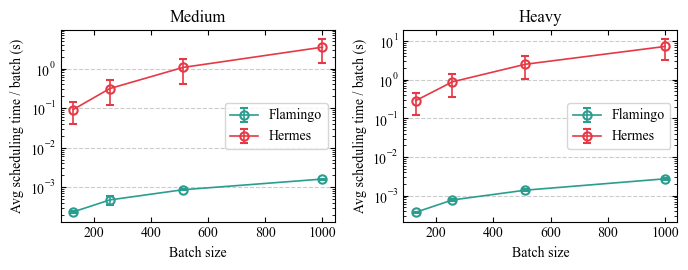

In [20]:
# Aggregate across seeds: mean ± std grouped by scheduler + tx_size_dist + batch_size
bs_agg = (
    df.groupby(['scheduler', 'tx_size_dist', 'batch_size'])['avg_runtime_per_batch_s']
    .agg(['mean', 'std'])
    .reset_index()
)

tx_sizes = ['medium', 'heavy']
colors = {'best_program': '#2a9d8f', 'paper': '#e63946'}
labels = {'best_program': 'Flamingo', 'paper': 'Hermes'}

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=False)

for ax, tx in zip(axes, tx_sizes):
    sub = bs_agg[bs_agg['tx_size_dist'] == tx]
    for sched in ['best_program', 'paper']:
        s = sub[sub['scheduler'] == sched].sort_values('batch_size')
        ax.errorbar(s['batch_size'], s['mean'], yerr=s['std'],
                    marker='o', capsize=3, color=colors[sched], label=labels[sched],
                    markerfacecolor='none', markeredgewidth=1.5, linewidth=1.2)
    ax.set_title(tx.capitalize())
    ax.set_xlabel('Batch size')
    ax.set_ylabel('Avg scheduling time / batch (s)')
    ax.set_yscale('log')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#aaaaaa')
    ax.set_axisbelow(True)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.legend(loc='best')

plt.tight_layout()
plt.savefig('sweep_time_batchsize.png', dpi=300, bbox_inches='tight')
plt.savefig('sweep_time_batchsize.pdf', bbox_inches='tight')
plt.show()

In [21]:
# # Aggregate across seeds: mean ± std grouped by scheduler + tx_size_dist + num_executors
# # Only use batch_size=1000
# ne_agg = (
#     df[df['batch_size'] == 1000]
#     .groupby(['scheduler', 'tx_size_dist', 'num_executors'])['avg_runtime_per_batch_s']
#     .agg(['mean', 'std'])
#     .reset_index()
# )

# fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=False)

# for ax, tx in zip(axes, tx_sizes):
#     sub = ne_agg[ne_agg['tx_size_dist'] == tx]
#     for sched in ['best_program', 'paper']:
#         s = sub[sub['scheduler'] == sched].sort_values('num_executors')
#         ax.errorbar(s['num_executors'], s['mean'], yerr=s['std'],
#                     marker='o', capsize=3, color=colors[sched], label=labels[sched],
#                     markerfacecolor='none', markeredgewidth=1.5, linewidth=1.2)
#     ax.set_title(tx.capitalize())
#     ax.set_xlabel('Number of executors')
#     ax.set_ylabel('Avg scheduling time / batch (s)')
#     ax.set_yscale('log')
#     ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#aaaaaa')
#     ax.set_axisbelow(True)
#     ax.tick_params(which='both', direction='in', top=True, right=True)
#     ax.legend(loc='best')

# plt.tight_layout()
# plt.savefig('sweep_time_executors.png', dpi=300, bbox_inches='tight')
# plt.savefig('sweep_time_executors.pdf', bbox_inches='tight')
# plt.show()